# 02 — Stylised Loan Portfolio Construction

**Purpose**: Build the stylised loan portfolio that underpins all four financial decision simulations.

**Input**: Clean property data and triangular fitted distributions from Notebook 01.

**Output**: `data/processed/portfolio.csv` — one row per loan/property with heterogeneous loan characteristics and physical risk fields.

**Design**:
- 100 loans, one per CFRF/GARP property (1:1 mapping preserves the empirical physical risk profile)
- Loan characteristics (EAD, maturity, baseline PD, LGD) drawn independently from parametric distributions in `config/parameters.yaml`
- Heterogeneity is deliberate: the SICR staging threshold interacts with baseline credit quality, so a portfolio of identical loans would understate the range of financial outcomes
- Zero-damage properties (20/100) are included as loans with no climate-driven uncertainty

This notebook is **shared infrastructure** — the saved portfolio is loaded by all decision-specific notebooks.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import yaml
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path(".").resolve().parent.parent / "src"))

from portfolio.construction import build_portfolio
from utils.plotting import set_style, COLOURS

set_style()

# Ensure output directories exist
Path("../../outputs/figures/shared").mkdir(parents=True, exist_ok=True)
Path("../../data/processed").mkdir(parents=True, exist_ok=True)

# Load config
with open("../../config/parameters.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Config loaded. Portfolio seed:", config["portfolio"]["random_seed"])

Config loaded. Portfolio seed: 42


## 1. Load data from Notebook 01

In [2]:
# Clean property data
df = pd.read_csv("../../data/processed/cfrf_garp_clean.csv")
print(f"Properties loaded: {len(df)}")

# Triangular fit results (primary distribution)
fit_results = pd.read_csv("../../data/processed/fitted_distributions_triangular.csv")
print(f"Fit results loaded: {len(fit_results)} rows")

assert len(df) == len(fit_results), "Row count mismatch between data and fit results"

# Summarise physical risk coverage
zero_mask = fit_results["is_zero_damage"]
print(f"\nZero-damage properties:         {zero_mask.sum()} (included as point masses)")
print(f"Properties with uncertainty:    {(~zero_mask).sum()}")

Properties loaded: 100
Fit results loaded: 100 rows

Zero-damage properties:         20 (included as point masses)
Properties with uncertainty:    80


## 2. Build the portfolio

In [5]:
portfolio = build_portfolio(config, df, fit_results)

print(f"Portfolio size: {len(portfolio)} loans")
print(f"\nColumns: {list(portfolio.columns)}")
print("\nSample (first 10 rows):")
portfolio.head(10)

Portfolio size: 100 loans

Columns: ['property_rank', 'ead_m', 'maturity_years', 'baseline_pd_12m', 'baseline_lgd', 'baseline_pd_lt', 'baseline_ecl_m', 'd_min', 'd_mean', 'd_max', 'vendor_spread', 'is_zero_damage', 'tri_mode', 'tri_clamped']

Sample (first 10 rows):


,property_rank,ead_m,maturity_years,baseline_pd_12m,baseline_lgd,baseline_pd_lt,baseline_ecl_m,d_min,d_mean,d_max,vendor_spread,is_zero_damage,tri_mode,tri_clamped
0,1,3.982802,12,0.019988,0.424040,0.215167,0.033757,0.00,0.59,1.00,1.00,False,0.77,False
1,2,2.474953,24,0.002855,0.235062,0.066321,0.001661,0.25,0.50,1.00,0.75,False,0.25,False
2,3,4.363691,15,0.003572,0.338509,0.052255,0.005276,0.00,0.36,0.57,0.57,False,0.51,False
3,4,3.638156,19,0.001442,0.227144,0.027042,0.001191,0.00,0.31,0.79,0.79,False,0.14,False
4,5,0.923798,14,0.011465,0.368060,0.149076,0.003898,0.00,0.35,1.00,1.00,False,0.05,False
5,6,4.890301,10,0.001059,0.270308,0.010541,0.001400,0.22,0.61,1.00,0.78,False,0.61,False
6,7,3.925129,21,0.004987,0.364856,0.099672,0.007142,0.16,0.38,0.72,0.56,False,0.26,False
7,8,4.037289,25,0.001371,0.381749,0.033726,0.002114,0.00,0.38,1.00,1.00,False,0.14,False
8,9,1.076511,10,0.003384,0.392162,0.033324,0.001428,0.00,0.26,0.68,0.68,False,0.10,False
9,10,2.526737,21,0.006761,0.226935,0.132785,0.003877,0.11,0.39,1.00,0.89,False,0.11,True


In [6]:
# Summary statistics
print("=== Portfolio summary statistics ===")
print(f"\nEAD (£m):")
print(f"  Mean:   £{portfolio.ead_m.mean():.2f}m   Median: £{portfolio.ead_m.median():.2f}m")
print(f"  Range:  £{portfolio.ead_m.min():.2f}m – £{portfolio.ead_m.max():.2f}m")
print(f"  Total:  £{portfolio.ead_m.sum():.1f}m")

print(f"\nMaturity (years):")
print(f"  Mean:   {portfolio.maturity_years.mean():.1f}   Median: {portfolio.maturity_years.median():.0f}")
print(f"  Range:  {portfolio.maturity_years.min()} – {portfolio.maturity_years.max()}")

print(f"\nBaseline PD (12m):")
print(f"  Median: {portfolio.baseline_pd_12m.median()*100:.3f}%")
print(f"  Range:  {portfolio.baseline_pd_12m.min()*100:.3f}% – {portfolio.baseline_pd_12m.max()*100:.3f}%")

print(f"\nBaseline LGD:")
print(f"  Mean:   {portfolio.baseline_lgd.mean():.3f}   Range: {portfolio.baseline_lgd.min():.3f} – {portfolio.baseline_lgd.max():.3f}")

print(f"\nBaseline ECL (pre-climate):")
print(f"  Total:  £{portfolio.baseline_ecl_m.sum()*1000:.1f}k")
print(f"  As % of total EAD:  {portfolio.baseline_ecl_m.sum() / portfolio.ead_m.sum() * 100:.4f}%")

=== Portfolio summary statistics ===

EAD (£m):
  Mean:   £2.69m   Median: £2.61m
  Range:  £0.53m – £4.89m
  Total:  £269.0m

Maturity (years):
  Mean:   14.6   Median: 14
  Range:  5 – 25

Baseline PD (12m):
  Median: 0.419%
  Range:  0.078% – 2.346%

Baseline LGD:
  Mean:   0.328   Range: 0.203 – 0.448

Baseline ECL (pre-climate):
  Total:  £528.7k
  As % of total EAD:  0.1965%


## 3. Diagnostic plots — loan characteristics

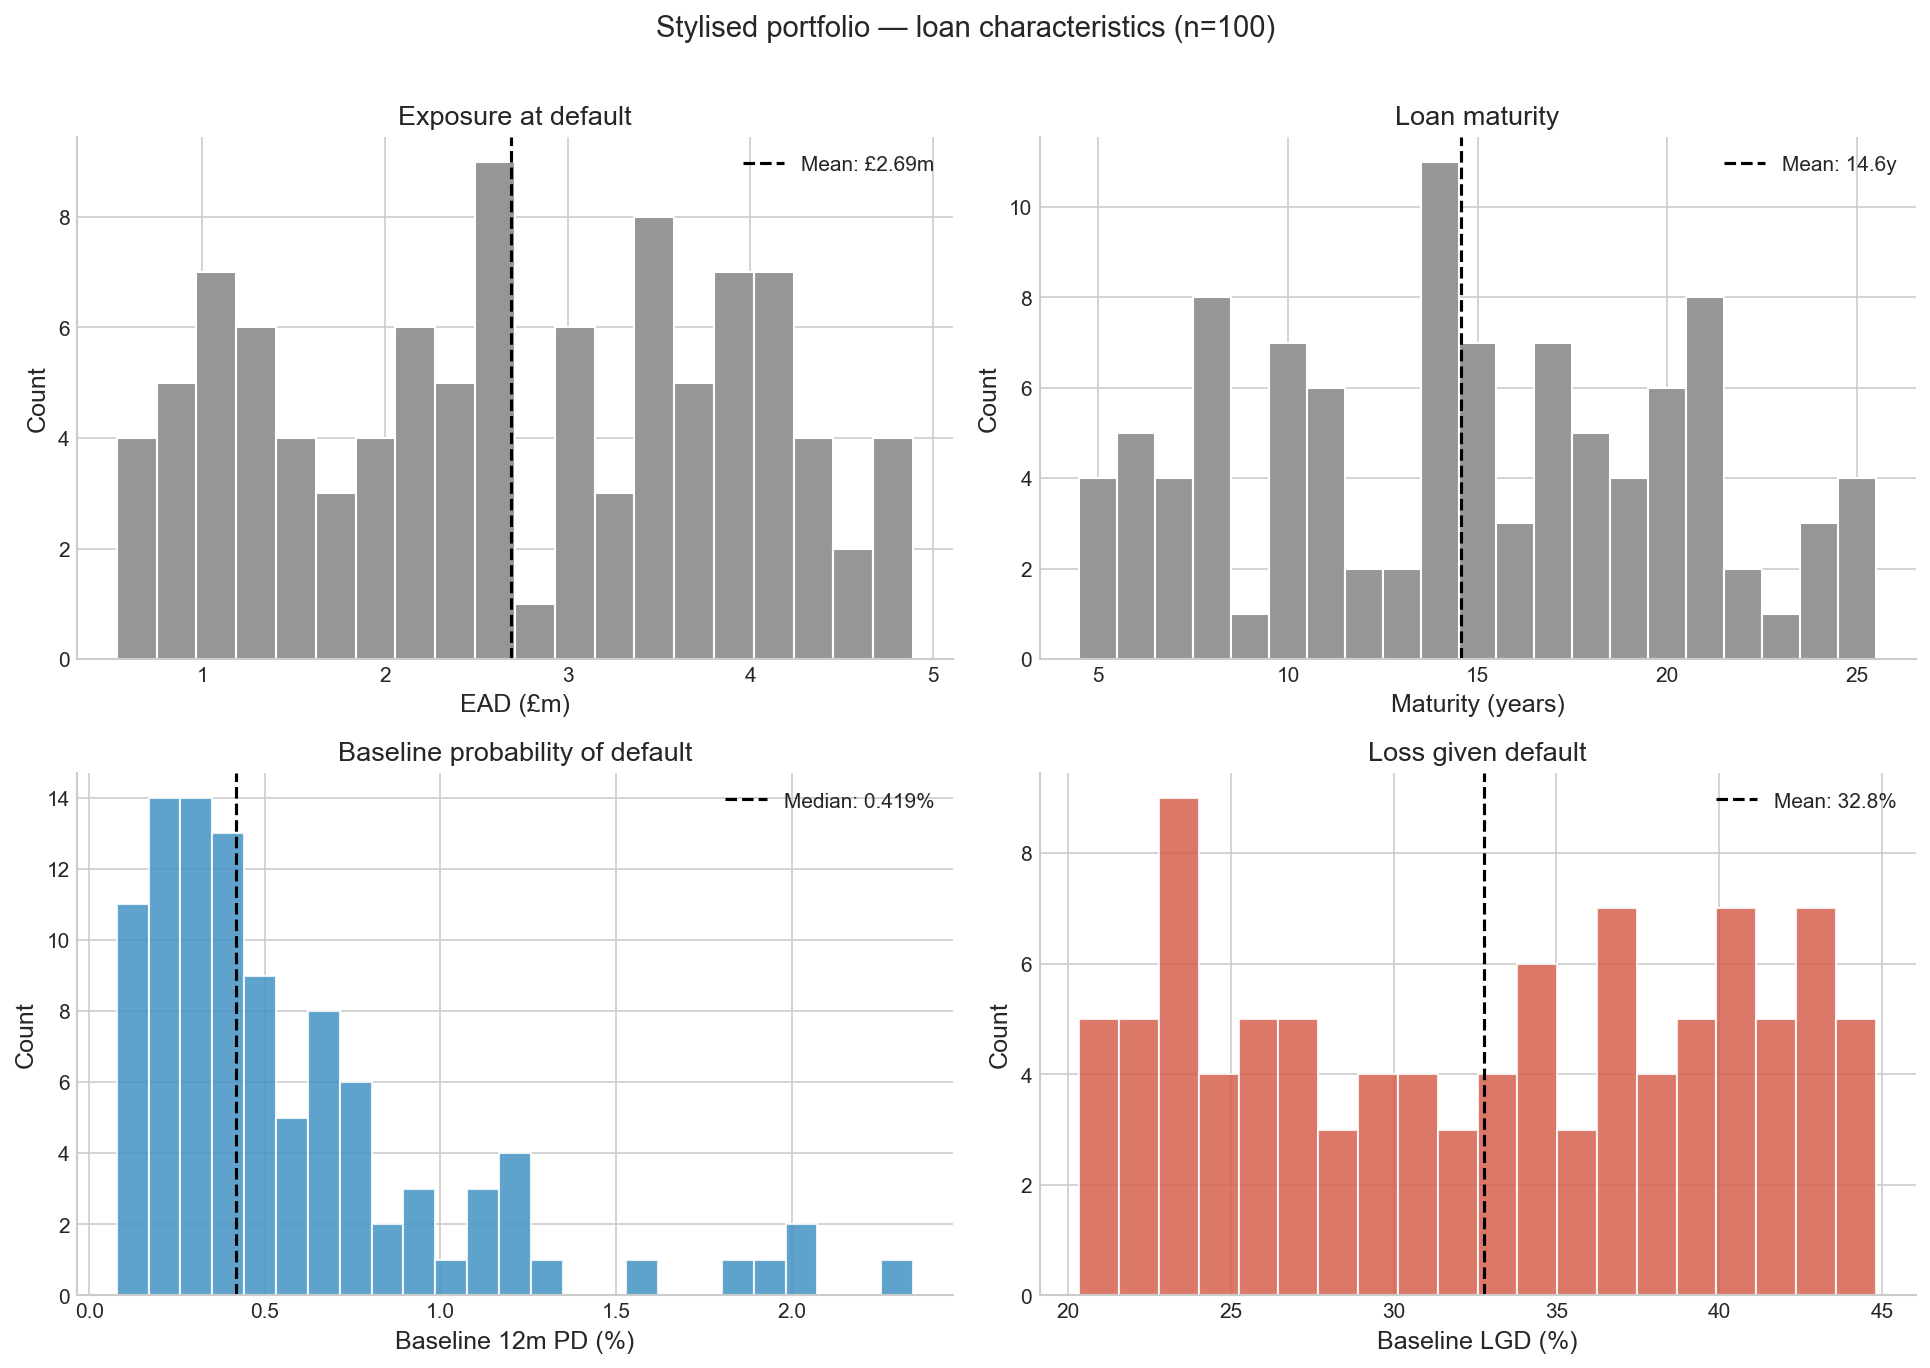

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

# EAD
ax = axes[0]
ax.hist(portfolio.ead_m, bins=20, color=COLOURS["grey"], edgecolor="white")
ax.axvline(portfolio.ead_m.mean(), color="k", lw=1.5, ls="--", label=f"Mean: £{portfolio.ead_m.mean():.2f}m")
ax.set_xlabel("EAD (£m)")
ax.set_ylabel("Count")
ax.set_title("Exposure at default")
ax.legend()

# Maturity
ax = axes[1]
ax.hist(portfolio.maturity_years, bins=range(5, 27), color=COLOURS["grey"], edgecolor="white", align="left")
ax.axvline(portfolio.maturity_years.mean(), color="k", lw=1.5, ls="--", label=f"Mean: {portfolio.maturity_years.mean():.1f}y")
ax.set_xlabel("Maturity (years)")
ax.set_ylabel("Count")
ax.set_title("Loan maturity")
ax.legend()

# Baseline PD (log scale)
ax = axes[2]
ax.hist(portfolio.baseline_pd_12m * 100, bins=25, color=COLOURS["stage1"], edgecolor="white", alpha=0.85)
ax.axvline(portfolio.baseline_pd_12m.median() * 100, color="k", lw=1.5, ls="--",
           label=f"Median: {portfolio.baseline_pd_12m.median()*100:.3f}%")
ax.set_xlabel("Baseline 12m PD (%)")
ax.set_ylabel("Count")
ax.set_title("Baseline probability of default")
ax.legend()

# Baseline LGD
ax = axes[3]
ax.hist(portfolio.baseline_lgd * 100, bins=20, color=COLOURS["stage2"], edgecolor="white", alpha=0.85)
ax.axvline(portfolio.baseline_lgd.mean() * 100, color="k", lw=1.5, ls="--",
           label=f"Mean: {portfolio.baseline_lgd.mean()*100:.1f}%")
ax.set_xlabel("Baseline LGD (%)")
ax.set_ylabel("Count")
ax.set_title("Loss given default")
ax.legend()

fig.suptitle("Stylised portfolio — loan characteristics (n=100)", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_loan_characteristics.png")
plt.show()

## 4. Physical risk profile — damage ratio vs. vendor uncertainty

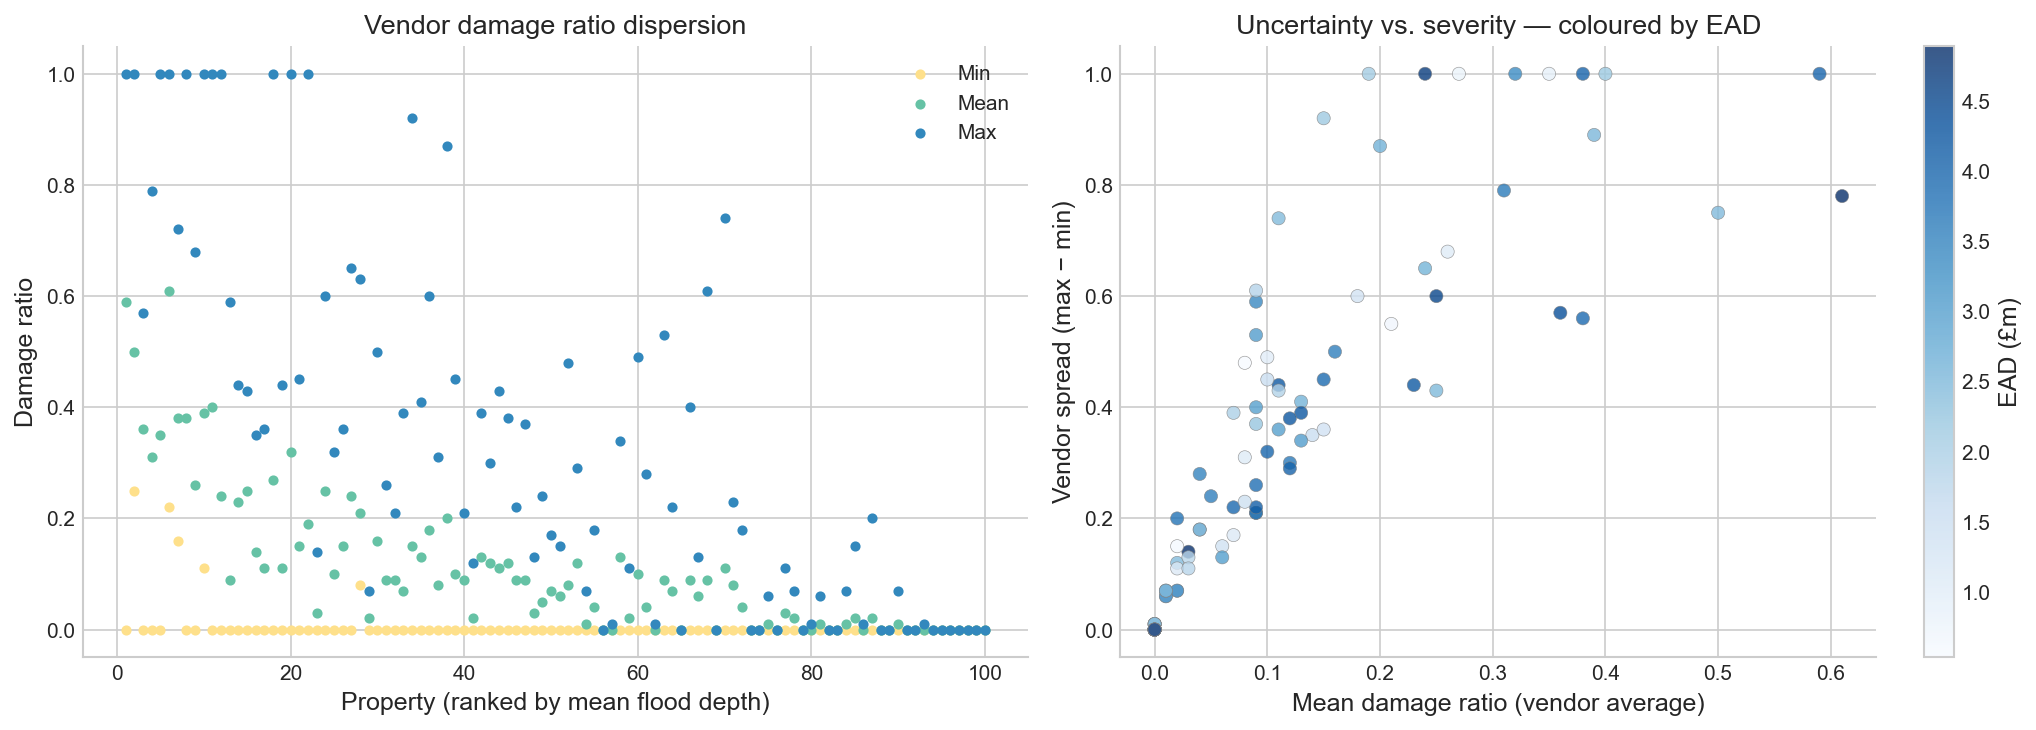

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: vendor min/mean/max across properties (sorted by mean DR)
ax = axes[0]
x = portfolio.property_rank
ax.scatter(x, portfolio.d_min,  c=COLOURS["data_min"],  s=15, label="Min",  zorder=3)
ax.scatter(x, portfolio.d_mean, c=COLOURS["data_mean"], s=15, label="Mean", zorder=3)
ax.scatter(x, portfolio.d_max,  c=COLOURS["data_max"],  s=15, label="Max",  zorder=3)
ax.set_xlabel("Property (ranked by mean flood depth)")
ax.set_ylabel("Damage ratio")
ax.set_title("Vendor damage ratio dispersion")
ax.legend()

# Right: vendor spread vs. mean DR — shows where uncertainty is concentrated
ax = axes[1]
sc = ax.scatter(
    portfolio.d_mean,
    portfolio.vendor_spread,
    c=portfolio.ead_m,
    cmap="Blues",
    s=40,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    zorder=3
)
plt.colorbar(sc, ax=ax, label="EAD (£m)")
ax.set_xlabel("Mean damage ratio (vendor average)")
ax.set_ylabel("Vendor spread (max − min)")
ax.set_title("Uncertainty vs. severity — coloured by EAD")

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_physical_risk_profile.png")
plt.show()

## 5. Baseline ECL distribution (pre-climate)

C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_32024\3344361342.py:36: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Mark.DESKTOP-UFHIN6T\AppData\Local\Temp\ipykernel_32024\3344361342.py:37: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig("../../outputs/figures/shared/portfolio_baseline_ecl.png")
C:\Users\Mark.DESKTOP-UFHIN6T\anaconda3\envs\garp-climate-risk\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


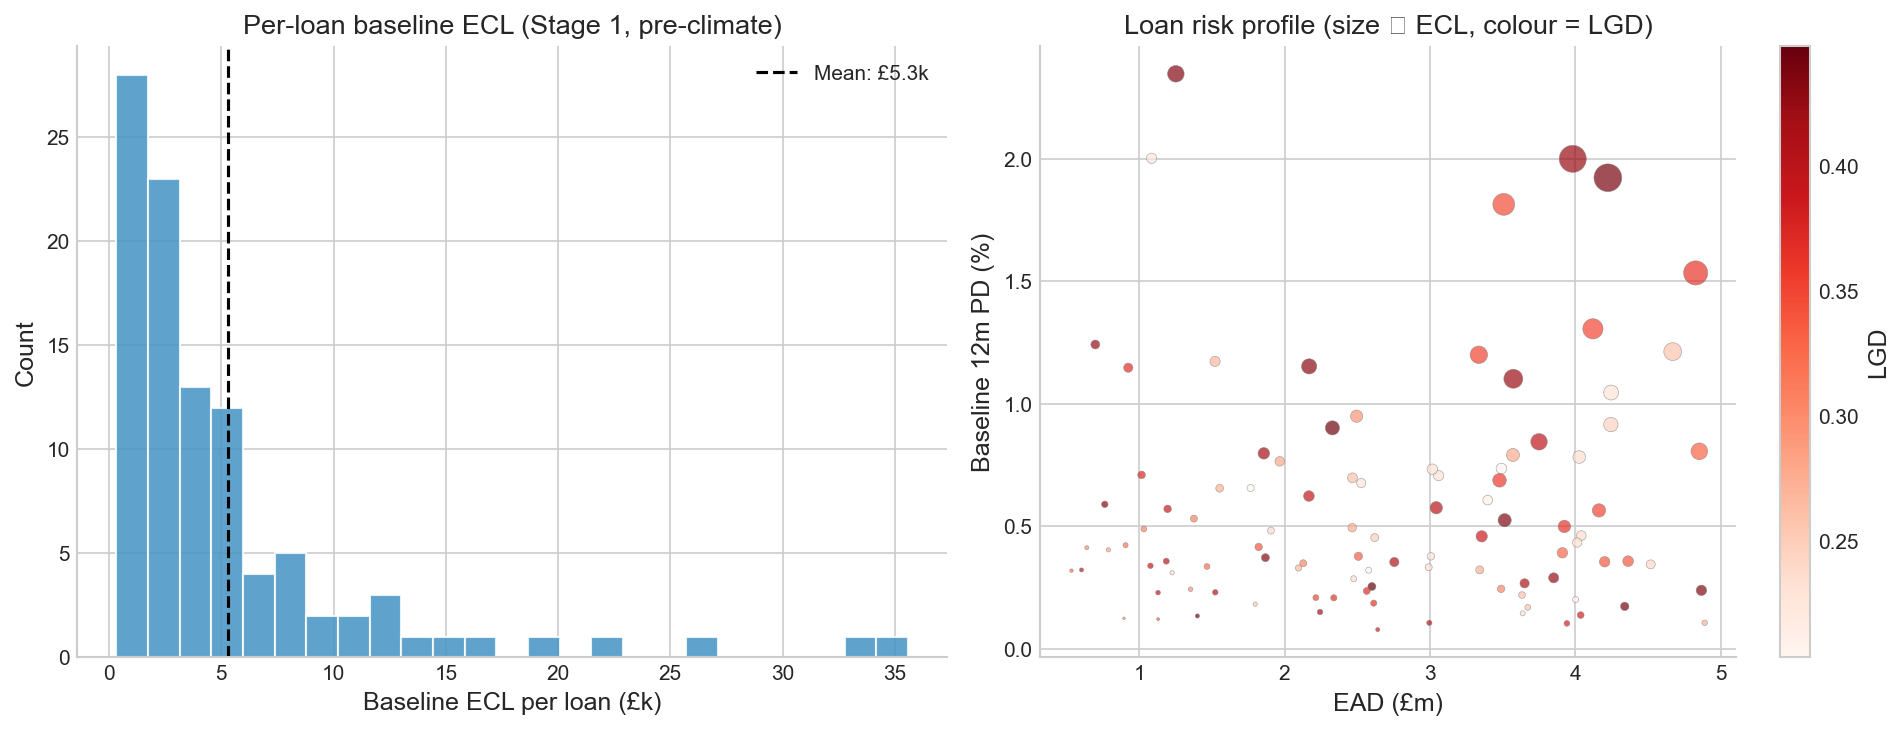

Total portfolio EAD:          £269.0m
Total baseline ECL (Stage 1): £528.7k
ECL / EAD (basis points):     19.65bp


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Per-loan baseline ECL in £k
ax = axes[0]
ecl_k = portfolio.baseline_ecl_m * 1000
ax.hist(ecl_k, bins=25, color=COLOURS["stage1"], edgecolor="white", alpha=0.85)
ax.axvline(ecl_k.mean(), color="k", lw=1.5, ls="--", label=f"Mean: £{ecl_k.mean():.1f}k")
ax.set_xlabel("Baseline ECL per loan (£k)")
ax.set_ylabel("Count")
ax.set_title("Per-loan baseline ECL (Stage 1, pre-climate)")
ax.legend()

# ECL vs EAD scatter — shows which loans dominate
ax = axes[1]
ax.scatter(
    portfolio.ead_m,
    portfolio.baseline_pd_12m * 100,
    c=portfolio.baseline_lgd,
    cmap="Reds",
    s=portfolio.baseline_ecl_m * 5000,   # size proportional to ECL
    alpha=0.7,
    edgecolors="grey",
    linewidths=0.3
)
ax.set_xlabel("EAD (£m)")
ax.set_ylabel("Baseline 12m PD (%)")
ax.set_title("Loan risk profile (size ∝ ECL, colour = LGD)")

# Add a manual legend for LGD colour
import matplotlib.patches as mpatches
sm = plt.cm.ScalarMappable(cmap="Reds",
    norm=plt.Normalize(portfolio.baseline_lgd.min(), portfolio.baseline_lgd.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="LGD")

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_baseline_ecl.png")
plt.show()

print(f"Total portfolio EAD:          £{portfolio.ead_m.sum():.1f}m")
print(f"Total baseline ECL (Stage 1): £{portfolio.baseline_ecl_m.sum()*1000:.1f}k")
print(f"ECL / EAD (basis points):     {portfolio.baseline_ecl_m.sum() / portfolio.ead_m.sum() * 10000:.2f}bp")

## 6. Interaction between credit quality and physical risk

In [10]:
# Key insight: SICR staging depends on both the climate damage AND the baseline PD.
# A loan with high baseline PD is already close to the SICR threshold — even a small
# damage ratio from a low-estimate vendor may be sufficient to trigger a stage migration.
# This plot previews that interaction.

cfg_cr = config["decision1_credit_risk"]
alpha = cfg_cr["alpha"]
tau = cfg_cr["sicr_threshold"]

# For each loan, compute the minimum damage ratio that would trigger SICR
# using the mean vendor estimate.
# SICR condition: PD_LT(d) / PD_LT(0) > tau
# PD_LT(d) = 1 - (1 - PD_0 * exp(alpha * d))^T
# Solve numerically for d_sicr
from scipy.optimize import brentq

d_sicr = np.full(len(portfolio), np.nan)
for i, row in portfolio.iterrows():
    pd0 = row.baseline_pd_12m
    T = row.maturity_years
    pd_lt_0 = 1 - (1 - pd0) ** T

    def sicr_gap(d):
        pd_adj = min(pd0 * np.exp(alpha * d), 1.0)
        pd_lt_adj = 1 - (1 - pd_adj) ** T
        return pd_lt_adj / pd_lt_0 - tau

    try:
        # d_sicr is the damage ratio at which the loan just crosses the SICR threshold
        d_sicr[i] = brentq(sicr_gap, 0, 1)
    except ValueError:
        # sicr_gap(0) > 0 → already in Stage 2 at zero damage (shouldn't happen)
        # sicr_gap(1) < 0 → never triggers SICR even at 100% damage
        d_sicr[i] = np.nan

portfolio["d_sicr_threshold"] = d_sicr

# How many loans could be triggered by their mean vendor estimate?
triggered_by_mean = portfolio.d_mean >= portfolio.d_sicr_threshold
triggered_by_max  = portfolio.d_max  >= portfolio.d_sicr_threshold
never_triggered   = portfolio.d_sicr_threshold.isna() | (portfolio.d_max < portfolio.d_sicr_threshold)

print(f"=== SICR sensitivity preview (alpha={alpha}, tau={tau}) ===")
print(f"Loans triggered by mean vendor estimate:  {triggered_by_mean.sum()}")
print(f"Loans triggered by max vendor estimate:   {triggered_by_max.sum()}")
print(f"Loans never triggered (even at max DR):   {never_triggered.sum()}")
print(f"Vendor uncertainty band straddles threshold: {(triggered_by_max & ~triggered_by_mean).sum()}")

=== SICR sensitivity preview (alpha=2.0, tau=2.0) ===
Loans triggered by mean vendor estimate:  8
Loans triggered by max vendor estimate:   39
Loans never triggered (even at max DR):   61
Vendor uncertainty band straddles threshold: 31


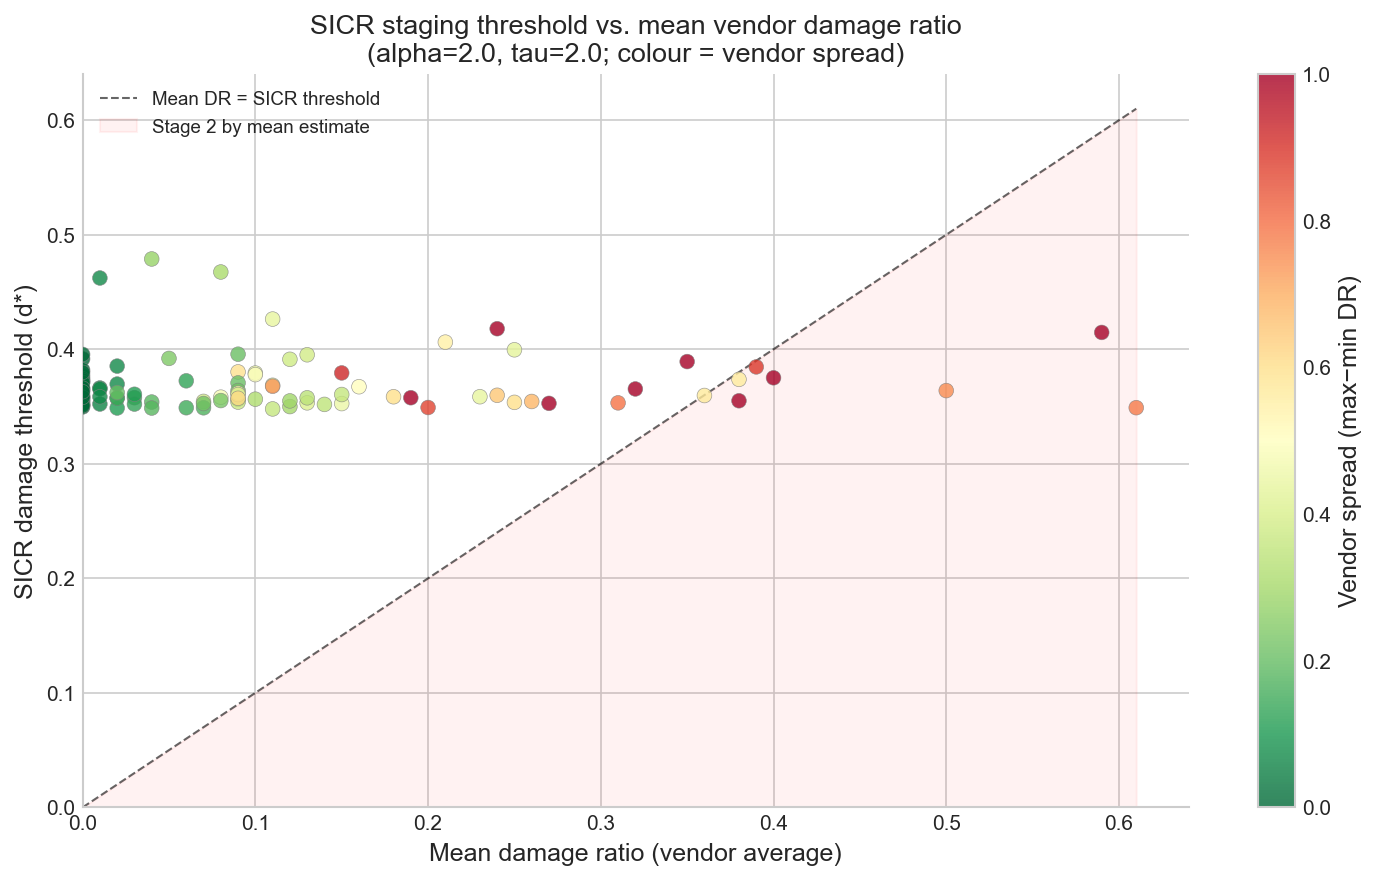

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot SICR threshold vs. mean damage ratio — coloured by vendor spread
valid = portfolio.d_sicr_threshold.notna()

sc = ax.scatter(
    portfolio.loc[valid, "d_mean"],
    portfolio.loc[valid, "d_sicr_threshold"],
    c=portfolio.loc[valid, "vendor_spread"],
    cmap="RdYlGn_r",
    s=50,
    alpha=0.8,
    edgecolors="grey",
    linewidths=0.3,
    zorder=3,
)
plt.colorbar(sc, ax=ax, label="Vendor spread (max−min DR)")

# 45° line: where mean DR = SICR threshold (loan triggered by mean estimate)
lim = max(portfolio.loc[valid, ["d_mean", "d_sicr_threshold"]].max().max(), 0.1)
ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.6, label="Mean DR = SICR threshold")

# Shade region where loan is triggered by mean estimate
ax.fill_between([0, lim], [0, 0], [0, lim], alpha=0.05, color="red", label="Stage 2 by mean estimate")

ax.set_xlabel("Mean damage ratio (vendor average)")
ax.set_ylabel("SICR damage threshold (d*)")
ax.set_title(
    f"SICR staging threshold vs. mean vendor damage ratio\n"
    f"(alpha={alpha}, tau={tau}; colour = vendor spread)"
)
ax.legend(fontsize=9)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("../../outputs/figures/shared/portfolio_sicr_threshold_preview.png")
plt.show()

## 7. Save portfolio

In [12]:
portfolio.to_csv("../../data/processed/portfolio.csv", index=False)

print("Saved: data/processed/portfolio.csv")
print(f"Shape: {portfolio.shape}")
print(f"Columns: {list(portfolio.columns)}")

Saved: data/processed/portfolio.csv
Shape: (100, 15)
Columns: ['property_rank', 'ead_m', 'maturity_years', 'baseline_pd_12m', 'baseline_lgd', 'baseline_pd_lt', 'baseline_ecl_m', 'd_min', 'd_mean', 'd_max', 'vendor_spread', 'is_zero_damage', 'tri_mode', 'tri_clamped', 'd_sicr_threshold']


## 8. Notes for downstream notebooks

**Portfolio schema**: `portfolio.csv` contains one row per loan with the following fields used downstream:

| Column | Description |
|--------|-------------|
| `property_rank` | Links back to CFRF/GARP physical risk data |
| `ead_m` | Exposure at default (£m) |
| `maturity_years` | Loan term (years) |
| `baseline_pd_12m` | Baseline 12-month PD (pre-climate) |
| `baseline_lgd` | Baseline LGD |
| `baseline_pd_lt` | Baseline lifetime PD = 1−(1−PD₀)ᵀ |
| `baseline_ecl_m` | Baseline Stage 1 ECL = PD₁₂m × LGD × EAD (£m) |
| `d_min/mean/max` | Vendor min/mean/max damage ratio |
| `vendor_spread` | d_max − d_min |
| `is_zero_damage` | True for 20 properties with no flood damage |
| `tri_mode` | Fitted triangular mode |
| `tri_clamped` | Whether mode was clamped to boundary |
| `d_sicr_threshold` | Damage ratio at which SICR triggers (alpha from config) |

**SICR threshold preview**: With alpha=2, tau=2 (EBA doubling rule), the vendor uncertainty band straddles the SICR threshold for a material number of loans — these are the loans where vendor choice matters most for IFRS 9 provisioning.

**Next step**: Notebook 03 maps the triangular damage ratio distribution through to adjusted PD/LGD for each loan, and Notebook 04 runs the full ECL simulation.